In [26]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

mask = dat["wf_cost"] < 3e-5  # Filter bad samples
nmask = np.sum(mask)
nmask

92

Text(0, 0.5, 'U')

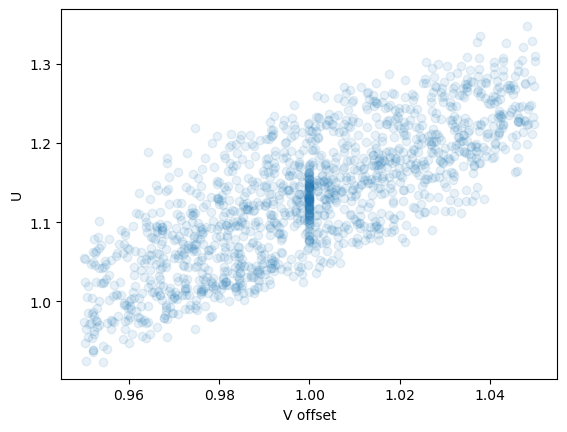

In [27]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

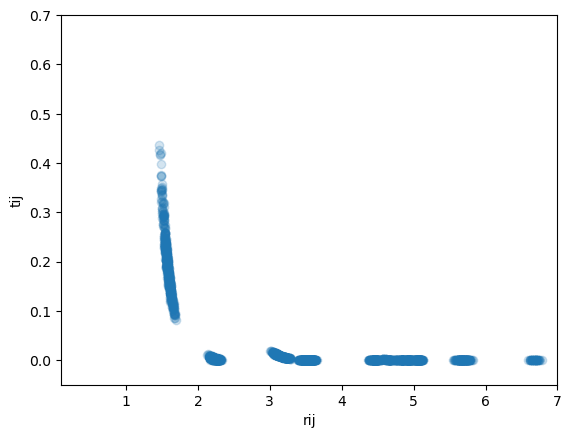

In [18]:
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

ValueError: x and y must be the same size

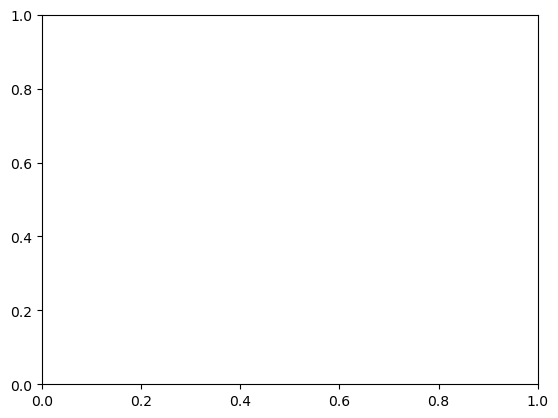

In [6]:
plt.scatter(np.min(dat["rij"][mask]), dat["wf_cost"][mask], alpha=0.1)
plt.xlabel("min(r_ij)")
plt.ylabel("U")